In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid",context="notebook")

df = pd.read_csv('/content/data.csv')

# Analyzing the Dataset

In [ ]:
df.head(3)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.isna().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


# **Customers Demographic Analysis**

### **Age-Group Distribution**

In [11]:
df["y_numeric"] = df["y"].map({"no": 0, "yes": 1})

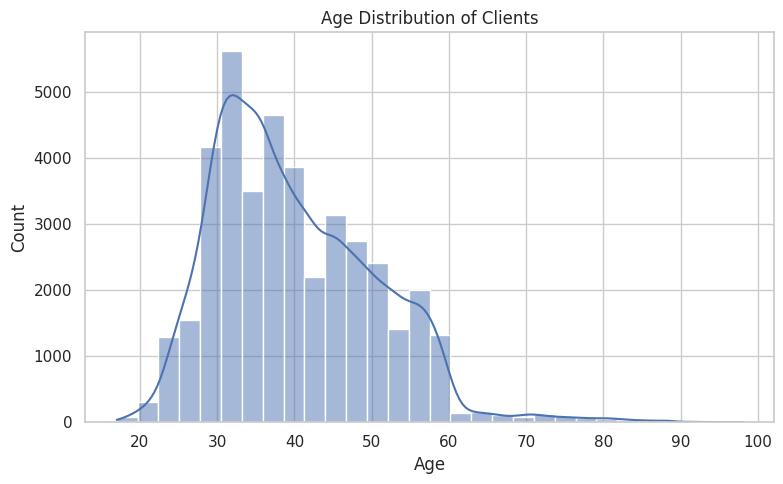

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df,x="age",bins=30,kde=True)

plt.title("Age Distribution of Clients")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

**Most customers fall within middle-aged groups, with fewer very young or very old customers.**

###**Job-Distribution**

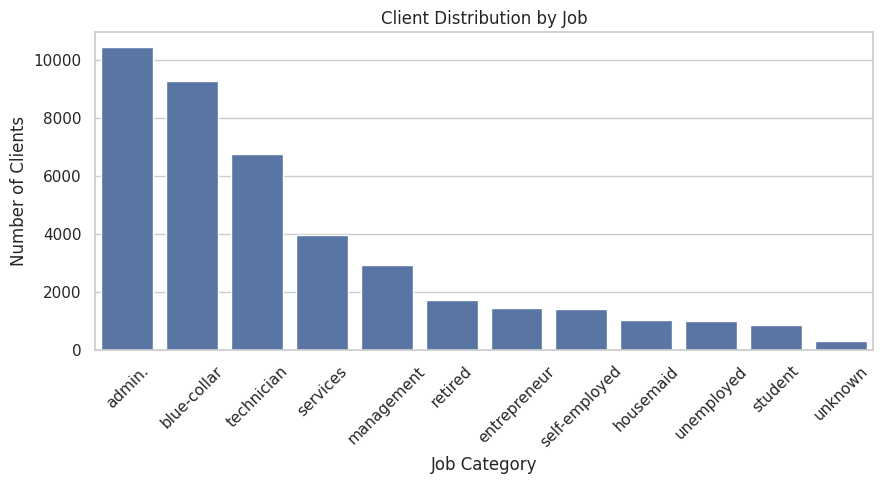

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df,x="job",order=df["job"].value_counts().index)

plt.title("Client Distribution by Job")
plt.xlabel("Job Category")
plt.ylabel("Number of Clients")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Certain professions (admin, blue-collar, technician, student) dominate the dataset.**

# **Campaign Effectiveness**

###**Contact Method Analysis**

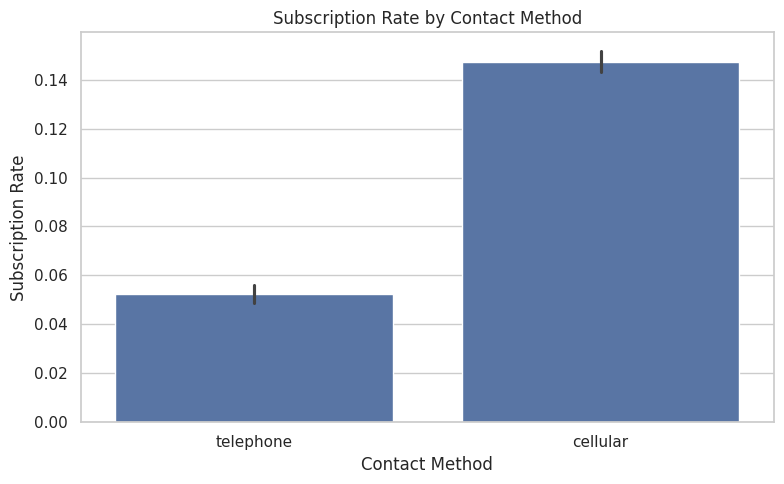

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df,x="contact",y="y_numeric",estimator="mean",errorbar=("ci", 95))

plt.title("Subscription Rate by Contact Method")
plt.xlabel("Contact Method")
plt.ylabel("Subscription Rate")

plt.tight_layout()
plt.show()

**Cellular contact performs better than telephone.**


# **Number Of Contact VS subscription**

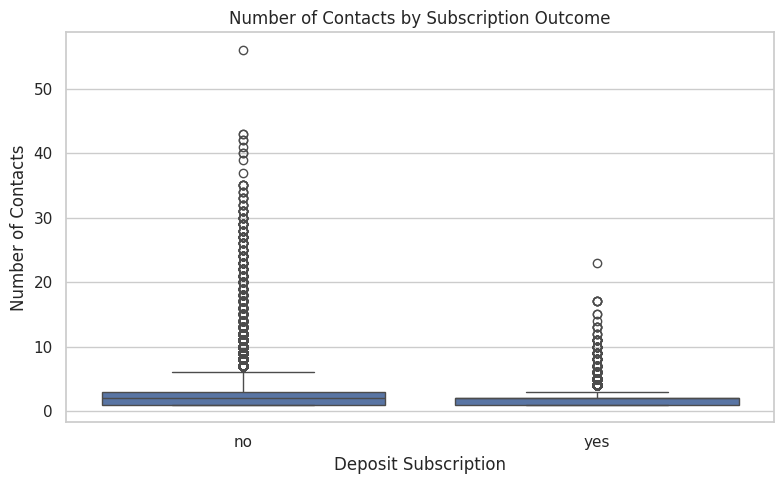

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df,x="y",y="campaign")

plt.title("Number of Contacts by Subscription Outcome")
plt.xlabel("Deposit Subscription")
plt.ylabel("Number of Contacts")

plt.tight_layout()
plt.show()

/tmp/ipython-input-2081018392.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('campaign-group')['y']


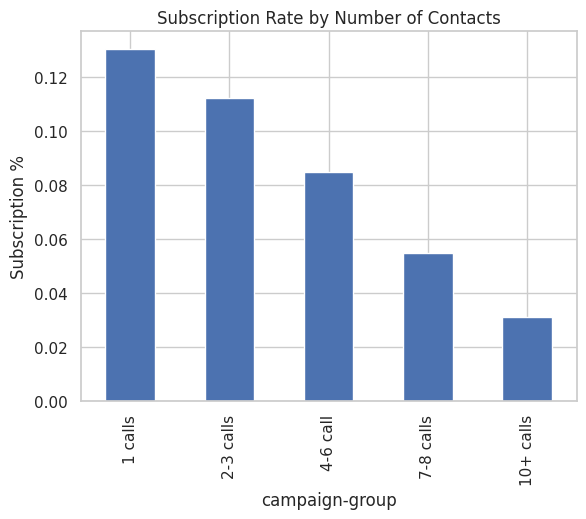

In [ ]:
df['campaign-group'] = pd.cut(df['campaign'],                                   #creating campaign-groups
                              bins=[0, 1,  3,  6, 10 ,df['campaign'].max()]
                              ,labels=['1 calls','2-3 calls','4-6 call','7-8 calls', '10+ calls'])

(df.groupby('campaign-group')['y']
 .value_counts(normalize=True)
 .unstack()['yes']
 .plot(kind='bar'))

plt.title('Subscription Rate by Number of Contacts')
plt.ylabel('Subscription %')
plt.show()

**Subscription rate decreases as the number of contacts increases.**

# **Correlation HeatMap**

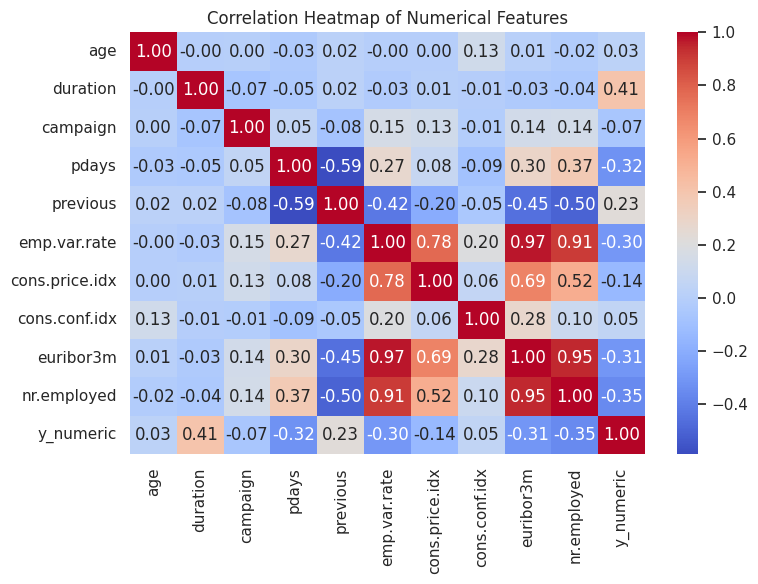

In [ ]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(8, 6))

sns.heatmap(numeric_df.corr(),annot=True,fmt=".2f",cmap="coolwarm")

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

**Duration and balance show positive correlation with subscription-related behavior.**

# **Predictive Modeling (Logistic Regression)**

**Encoded Categorical Variable**

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df_model = df.copy()

label_cols = df_model.select_dtypes(include="object").columns

le = LabelEncoder()
for col in label_cols:
    df_model[col] = le.fit_transform(df_model[col])

**Train-Test Split Model**

In [19]:
df_model = df.copy()
le = LabelEncoder()
label_cols = df_model.select_dtypes(include="object").columns
for col in label_cols:
    df_model[col] = le.fit_transform(df_model[col])

X = df_model.drop(["y_numeric", "y"], axis=1, errors='ignore')
y = df_model["y_numeric"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

**Predictions**

In [20]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.42      0.51       935

    accuracy                           0.91      8238
   macro avg       0.80      0.69      0.73      8238
weighted avg       0.90      0.91      0.90      8238



**FEATURE IMPORTANCE (INTERPRETABLE)**

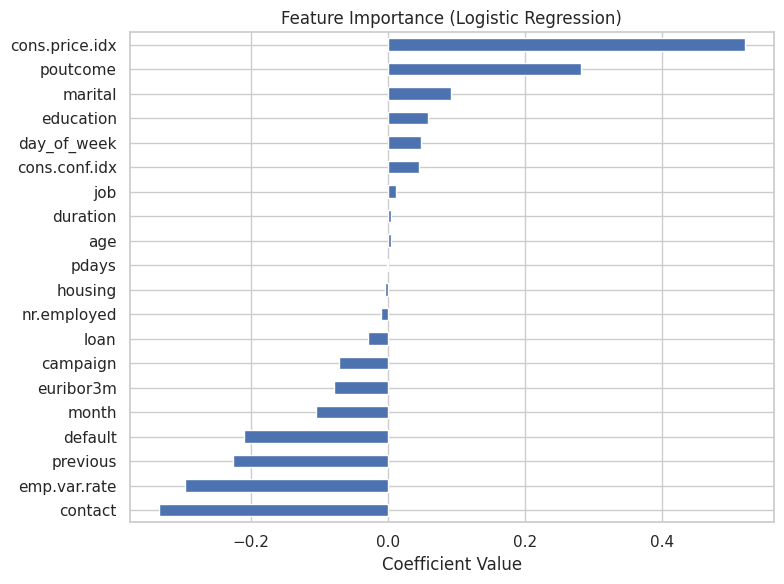

In [21]:
feature_importance = pd.Series(model.coef_[0],index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
feature_importance.plot(kind="barh")
plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")

plt.tight_layout()
plt.show()

**A simple Logistic Regression model was used to identify key factors influencing term deposit subscription. The results support EDA findings, showing that campaign behavior and customer characteristics together drive subscription likelihood.**